# Simulazione d'esame Laboratorio di Programmazione 2

## Esercizio 1

1. Crea un vettore NumPy con i seguenti **canoni mensili d'affitto** (in euro) per 4 appartamenti: **720, 980, 650, 1200**

2. Calcola la **spesa totale mensile** sostenuta dagli inquilini.

3. Il proprietario dell'appartamento da **1200 €** decide di **aumentare l’affitto del 12%**.
    - Modifica il vettore per applicare l’aumento.
    - L’importo aggiornato deve essere esattamente **1344,00 €**, controlla se appare **esattamente** nel tuo array.


4. L'inquilino dell'appartamento da **650 €** ottiene uno **sconto del 10%**.
    - Applica la modifica.

5. Gli altri due appartamenti (**720 € e 980 €**) subiscono un **aumento del 5%**.
    - Aggiorna il vettore di conseguenza.

7. Calcola la **nuova spesa totale mensile** dopo tutti i cambiamenti.

8. Infine: quanto ha influito **l’aumento dell’affitto più alto** sulla spesa complessiva?

    (Suggerimento: confronta la spesa totale **prima di qualsiasi modifica** e **dopo il solo aumento del canone a 1200 €**.)


In [15]:
# Step 1: Crea un vettore NumPy con i seguenti canoni mensili d'affitto (in euro) per 4 appartamenti: 720, 980, 650, 1200
import numpy as np

array = np.array([720, 980, 650, 1200], dtype = float)
print("Array: ", array)

Array:  [ 720.  980.  650. 1200.]


In [16]:
# Step 2: Calcola la spesa totale mensile sostenuta dagli inquilini.
tot = array.sum()
print("Spesa totale mensile: ", tot)

Spesa totale mensile:  3550.0


In [17]:
# Step 3: Il proprietario dell'appartamento da 1200 € decide di aumentare l’affitto del 12%.
# Modifica il vettore per applicare l’aumento.
# L’importo aggiornato deve essere esattamente 1344,00 €, controlla se appare esattamente nel tuo array.
array[array == 1200] *= 1.12
tot_agg = array.sum()

print("Array aggiornato: ", array)
print("Spesa: ", tot_agg)

Array aggiornato:  [ 720.  980.  650. 1344.]
Spesa:  3694.0


In [18]:
# Step 4: L'inquilino dell'appartamento da 650 € ottiene uno sconto del 10%. Applica la modifica.
array[array == 650] *= 0.9
print("Array aggiornato: ", array)

Array aggiornato:  [ 720.  980.  585. 1344.]


In [19]:
# Step 5: Gli altri due appartamenti (720 € e 980 €) subiscono un aumento del 5%. Aggiorna il vettore di conseguenza.
array[array == 720] *= 1.05
array[array == 980] *= 1.05
print("Array aggiornato: ", array)

Array aggiornato:  [ 756. 1029.  585. 1344.]


In [20]:
# Step 6: Calcola la nuova spesa totale mensile dopo tutti i cambiamenti.
sp_tot = array.sum()
print("Nuova spesa totale mensile: ", sp_tot)

Nuova spesa totale mensile:  3714.0


In [21]:
# Step 7: Quanto ha influito l’aumento dell’affitto più alto sulla spesa complessiva?
# (Suggerimento: confronta la spesa totale prima di qualsiasi modifica e dopo il solo aumento del canone a 1200 €.)

aumento1 = tot_agg - tot
aumento_tot = sp_tot - tot

print("Spesa dopo aumento di app 1: ", aumento1)
print("Spesa finale: ", aumento_tot)

Spesa dopo aumento di app 1:  144.0
Spesa finale:  164.0


## Esercizio 2

Consideriamo un semplice processo di random walk (cammino aleatorio) in una dimensione:
a ogni passo temporale, un camminatore si sposta a destra (+1) o a sinistra (-1) con uguale probabilità. Supponiamo che il camminatore parta sempre da x=0.

1. Scrivi una funzione che simula il cammino per n passi ed N camminatori e restituisce due array. Il primo rappresenta la media della posizione ad ogni passo degli N camminatori ed il secondo la deviazione standard della posizione ad ogni passo degli N camminatori.

2. Fai prima il plot della media delle posizione degli N camminatori per 100 passi 

3. Fai il plot con anche la devizione standard.  La deviazione standard diminuisce all'aumentare del campione? Che andamento ha la deviazione standard rispeto l tempo/passi?

In [22]:
# Step 1: Scrivi una funzione che simula il cammino per n passi ed N camminatori e restituisce due array. 
# Il primo rappresenta la media della posizione ad ogni passo degli N camminatori ed il secondo la deviazione standard della 
# posizione ad ogni passo degli N camminatori.
import numpy as np

rng = np.random.default_rng()

def sim_cammino(n, N):
    passi = np.random.choice([-1, 1], size=(N, n), replace=True, p=[0.5, 0.5])
    posizioni = np.cumsum(passi, axis=1)    # somma progressiva lungo le colonne (i passi)
    media = np.mean(posizioni, axis=0)      # axis=0 → "lungo le righe", cioè per ogni colonna/passo
    std = np.std(posizioni, axis=0)         # deviazione standard

    return media, std

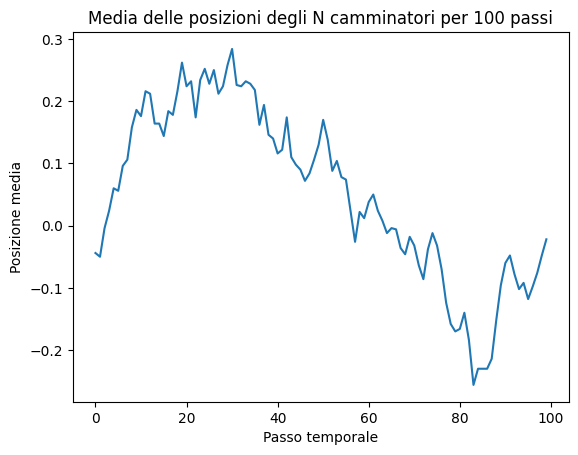

In [33]:
# Step 2: Fai prima il plot della media delle posizione degli N camminatori per 100 passi
import matplotlib.pyplot as plt

n = 100
N = 1000

media, std = sim_cammino(n, N)

plt.plot(media)
plt.title("Media delle posizioni degli N camminatori per 100 passi")
plt.xlabel("Passo temporale")
plt.ylabel("Posizione media")
plt.show()

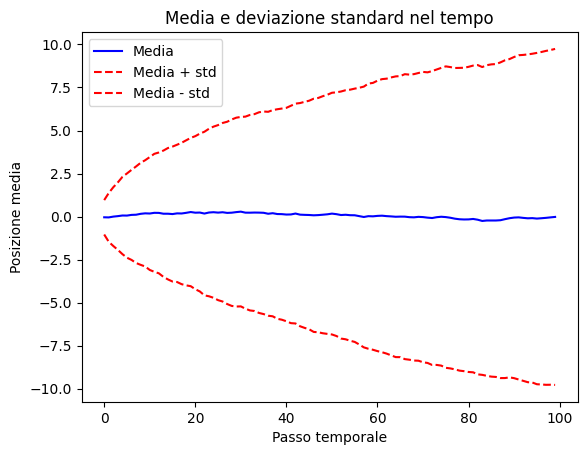

In [35]:
# Step 3: Fai il plot con anche la devizione standard. La deviazione standard diminuisce all'aumentare del campione? 
# Che andamento ha la deviazione standard rispeto l tempo/passi?

plt.plot(media, label="Media", color="blue")
plt.plot(media + std, label='Media + std', color='red', linestyle='--')
plt.plot(media - std, label='Media - std', color='red', linestyle='--')
plt.title("Media e deviazione standard nel tempo")
plt.xlabel("Passo temporale")
plt.ylabel("Posizione media")
plt.legend()
plt.show()

## Esercizio 3

Genera un array `a` di dimensioni **5 x 9** contenente numeri da una distribuzione gaussiana con media 0 e dev standard 1.  
Per ogni riga, seleziona il numero **più vicino a 0.1**.
Imposta il seed per la riproducibilità `np.random.seed(42)`

 *Suggerimento*: per ottenere `a[i, j]`, l'array `i` deve contenere gli **indici di riga** corrispondenti agli elementi in `j`.


In [40]:
import numpy as np
import pandas as pd

np.random.seed(42)
array = np.random.normal(loc=0, scale=1, size=(5,9))
print("Array: ", array)

distanza = np.abs(array - 0.1)

indice_col = np.argmin(distanza, axis=1)
indici_riga = np.arange(5)

risult = array[indici_riga, indice_col]
print("Risultato: ",risult)

Array:  [[ 0.49671415 -0.1382643   0.64768854  1.52302986 -0.23415337 -0.23413696
   1.57921282  0.76743473 -0.46947439]
 [ 0.54256004 -0.46341769 -0.46572975  0.24196227 -1.91328024 -1.72491783
  -0.56228753 -1.01283112  0.31424733]
 [-0.90802408 -1.4123037   1.46564877 -0.2257763   0.0675282  -1.42474819
  -0.54438272  0.11092259 -1.15099358]
 [ 0.37569802 -0.60063869 -0.29169375 -0.60170661  1.85227818 -0.01349722
  -1.05771093  0.82254491 -1.22084365]
 [ 0.2088636  -1.95967012 -1.32818605  0.19686124  0.73846658  0.17136828
  -0.11564828 -0.3011037  -1.47852199]]
Risultato:  [-0.1382643   0.24196227  0.11092259 -0.01349722  0.17136828]


## Esercizio 4

Utilizza il dataset `titanic`, disponibile all'url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

Esegui un’analisi esplorativa sui dati dei passeggeri, focalizzandoti su tariffe, età e componenti familiari.

1. **Visualizza i primi 10 passeggeri ordinati per tariffa pagata** (`Fare`), dal più alto al più basso.

2. **Calcola la media** di:
   - `Age` (età)
   - `Fare` (tariffa)
   - `SibSp` (numero di fratelli/coniugi a bordo)

3. **Crea una nuova colonna** chiamata `Family_index`, definita come:

   $$
   \texttt{family\_index} = \frac{\texttt{sibsp} + \texttt{parch}}{\texttt{fare}}
   $$

   *(Indicatore del “peso familiare” per unità di spesa – attenzione a eventuali divisioni per zero!)*

4. Trova il **passeggero con il valore massimo** di `Family_index`.

5. **Filtra solo i passeggeri** che hanno pagato **più di 100** di tariffa (`Fare > 100`).

6. **Crea un grafico a barre** con i 10 passeggeri che hanno pagato di più (`Fare`).

7. **Crea un grafico a linee** dell’età (`Age`), ordinando i passeggeri per tariffa (`Fare`) crescente.



💡 *Suggerimenti*:
- Ricordati di gestire eventuali valori mancanti in `Age` o `Fare` prima di fare operazioni.


In [41]:
# Caricamento dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [42]:
# Step 1: visualizza i primi 10 passeggeri ordinati per tariffa pagata (`Fare`), dal più alto al più basso
df10_pass = df.sort_values(by="Fare", ascending=False).head(10)
df10_pass

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0000,C23 C25 C27,S
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,C23 C25 C27,S
341,342,1,1,"Fortune, Miss. Alice Elizabeth",female,24.0,3,2,19950,263.0000,C23 C25 C27,S
438,439,0,1,"Fortune, Mr. Mark",male,64.0,1,4,19950,263.0000,C23 C25 C27,S
311,312,1,1,"Ryerson, Miss. Emily Borie",female,18.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C
742,743,1,1,"Ryerson, Miss. Susan Parker ""Suzette""",female,21.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C
118,119,0,1,"Baxter, Mr. Quigg Edmond",male,24.0,0,1,PC 17558,247.5208,B58 B60,C


In [43]:
# Step 2: calcola la media di: `Age` (età),`Fare` (tariffa) e `SibSp` (numero di fratelli/coniugi a bordo)
med_anni = df["Age"].mean()
med_tariffa = df["Fare"].mean()
med_fam = df["SibSp"].mean()

print("La media d'età è: ", med_anni)
print("Media tariffa: ", med_tariffa)
print("Media numero di fratelli/coniugi: ", med_fam)

La media d'età è:  29.69911764705882
Media tariffa:  32.204207968574636
Media numero di fratelli/coniugi:  0.5230078563411896


In [45]:
# Step 3: crea una nuova colonna chiamata `Family_index`, definita come sopra
df["Family_index"] = (df["SibSp"] + df["Parch"])/df["Fare"]
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family_index
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0.137931
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,0.014029
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0.000000
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,0.018832
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,0.000000
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,0.000000
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,0.127932
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,0.000000


In [48]:
# Step 4: trova il passeggero con il valore massimo di `Family_index'
pass_fam_max = df["Family_index"].idxmax()
nome = df.loc[pass_fam_max, "Name"]
print("Passeggero con Family_index massimo: ", nome)

Passeggero con Family_index massimo:  Andersson, Miss. Erna Alexandra


In [57]:
# Step 5: filtra solo i passeggeri che hanno pagato più di 100 di tariffa (`Fare > 100`)
df_100 = df[df["Fare"] > 100]
df_100
# df_100.groupby("Name")["Fare"]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family_index
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.00,3,2,19950,263.0000,C23 C25 C27,S,0.019011
31,32,1,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,NaN,1,0,PC 17569,146.5208,B78,C,0.006825
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.00,3,2,19950,263.0000,C23 C25 C27,S,0.019011
118,119,0,1,"Baxter, Mr. Quigg Edmond",male,24.00,0,1,PC 17558,247.5208,B58 B60,C,0.004040
195,196,1,1,"Lurette, Miss. Elise",female,58.00,0,0,PC 17569,146.5208,B80,C,0.000000
215,216,1,1,"Newell, Miss. Madeleine",female,31.00,1,0,35273,113.2750,D36,C,0.008828
258,259,1,1,"Ward, Miss. Anna",female,35.00,0,0,PC 17755,512.3292,NaN,C,0.000000
268,269,1,1,"Graham, Mrs. William Thompson (Edith Junkins)",female,58.00,0,1,PC 17582,153.4625,C125,S,0.006516
269,270,1,1,"Bissette, Miss. Amelia",female,35.00,0,0,PC 17760,135.6333,C99,S,0.000000
297,298,0,1,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S,0.019795


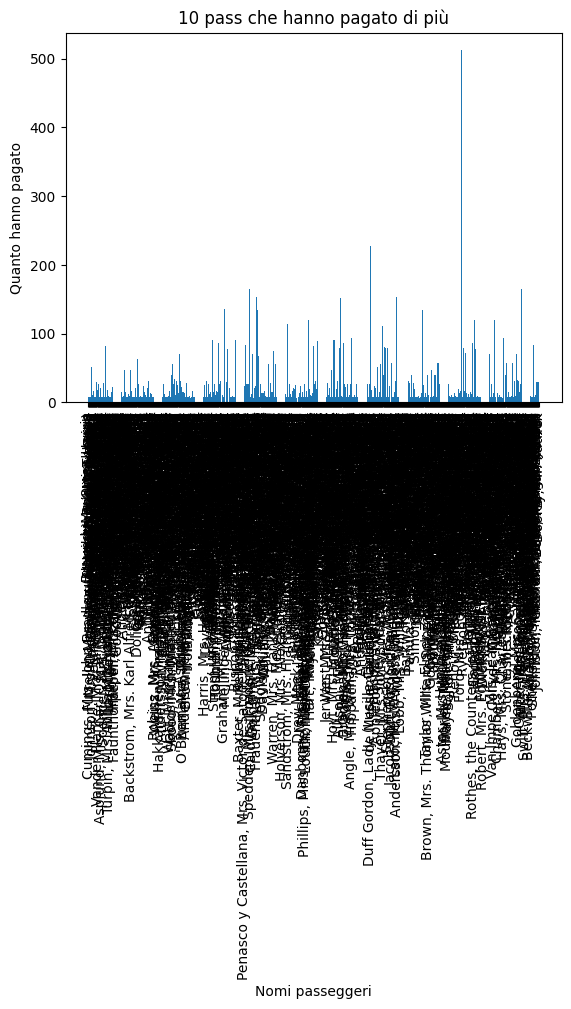

In [62]:
# Step 6: crea un grafico a barre con i 10 passeggeri che hanno pagato di più (`Fare`)
df_top10 = df_100.head(10)
plt.bar(df["Name"], df["Fare"])
plt.title("10 pass che hanno pagato di più")
plt.xlabel("Nomi passeggeri")
plt.xticks(rotation=90)
plt.ylabel("Quanto hanno pagato")
plt.show()

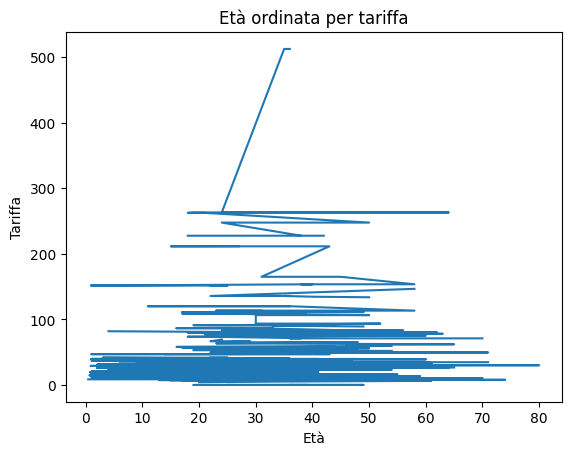

In [67]:
# Step 7: crea un grafico a linee dell’età (`Age`), ordinando i passeggeri per tariffa (`Fare`) crescente
df_new = df.sort_values(by="Fare", ascending=True)

plt.plot(df_new["Age"],df_new["Fare"])
plt.title("Età ordinata per tariffa")
plt.xlabel("Età")
plt.ylabel("Tariffa")
plt.show()

# plt.scatter(df_new["Age"], df_new["Fare"], s=50, alpha=0.7)
# plt.title("Età ordinata per tariffa")
# plt.xlabel("Età")
# plt.ylabel("Tariffa")
# plt.show()

## Esercizio 5

Usa il dataset `penguins`, disponibile tramite `seaborn.load_dataset("penguins")`.


1. Quante righe e colonne ha il dataset?

2. Controlla quanti valori mancanti ci sono per colonna.

3. Riempi i valori mancanti nella colonna `sex` con il valore più frequente.

4. Rimuovi le righe in cui il valore `body_mass_g` è mancante.

5. Controlla se ci sono righe duplicate.

6. Calcola la **massa corporea media** (`body_mass_g`) per ogni specie (`species`).
  Se ci sono valori mancanti in `body_mass_g`, riempili con la media della specie.

7. Visualizza la **distribuzione della massa corporea** (`body_mass_g`) per specie.

8.  Visualizza la **distribuzione della massa corporea** per specie, **dividendo per sesso** (`sex`) e mostrandoli a confronto.


💡 Suggerimento: usa `seaborn.violinplot()`, `boxplot()` o `kdeplot()` con `hue='sex'`.


In [72]:
# Caricamento
import seaborn as sns
df = sns.load_dataset("penguins")
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [74]:
# Step 1: quante righe e quante colonne ha il dataset
import matplotlib.pyplot as plt
import pandas as pd

righe, colonne = df.shape
print("Numero di righe: ", righe)
print("Numero di colonne: ", colonne)

Numero di righe:  344
Numero di colonne:  7


In [76]:
# Step 2: quanti valori mancanti ci sono per colonna
nan_colonna = df.isna().sum()
print("Valori mancanti per colonna: ", nan_colonna)

Valori mancanti per colonna:  species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


In [83]:
# Step 3: riemipi i valori mancanti nella colonna sex con il valore più frequante
freq_sex = df["sex"].mode()[0]
print("Valore più frequente di sex: ", freq_sex)

df["sex"] = df["sex"].fillna(freq_sex)
df

Valore più frequente di sex:  Male


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,Male
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,Male
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [88]:
# Step 4: rimuovere le righe in cui il valore `body_mass_g` è mancante
df = df.dropna(subset=['body_mass_g'])
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [90]:
# Step 5: controllare se ci sono righe duplicate
maschera_dup = df.duplicated()
print(maschera_dup)

0      False
1      False
2      False
4      False
5      False
       ...  
338    False
340    False
341    False
342    False
343    False
Length: 342, dtype: bool


In [94]:
# Step 6: calcolare la massa corporea media (`body_mass_g`) per ogni specie (`species`)
# Se ci sono valori mancanti in `body_mass_g`, riempili con la media della specie.
massa_media = df.groupby("species")["body_mass_g"].mean()
print("Massa media per specie: ", massa_media)

df["body_mass_g"] = df["body_mass_g"].fillna(df["species"].map(massa_media))
df

Massa media per specie:  species
Adelie       3700.662252
Chinstrap    3733.088235
Gentoo       5076.016260
Name: body_mass_g, dtype: float64


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


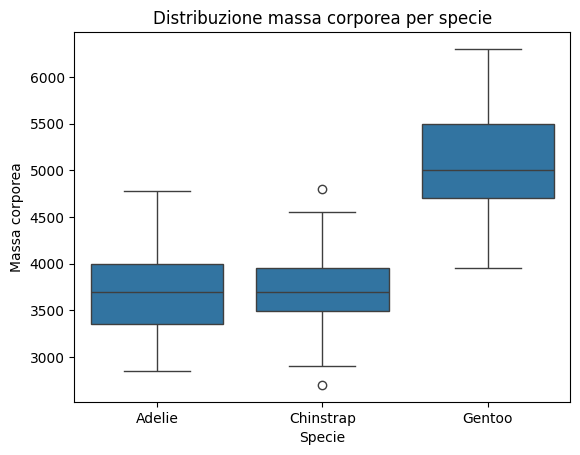

In [96]:
# Step 7: visualizzare la distribuzione della massa corporea (`body_mass_g`) per specie
sns.boxplot(data=df, x="species", y="body_mass_g")
plt.title("Distribuzione massa corporea per specie")
plt.xlabel("Specie")
plt.ylabel("Massa corporea")
plt.show()

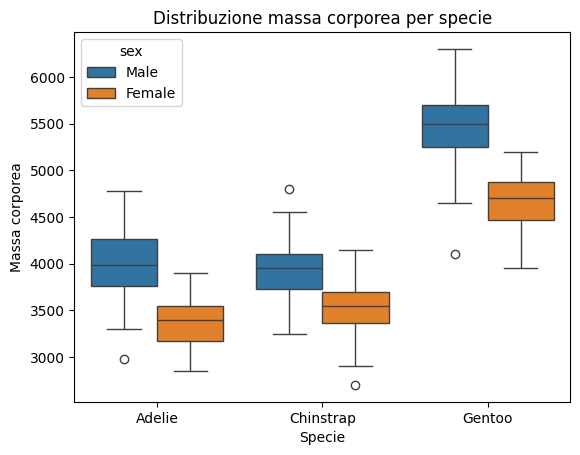

In [97]:
# Step 8: visualizzare la distribuzione della massa corporea per specie, dividendo per sesso (`sex`) e mostrandoli a confronto
sns.boxplot(data=df, x="species", y="body_mass_g", hue="sex")
plt.title("Distribuzione massa corporea per specie")
plt.xlabel("Specie")
plt.ylabel("Massa corporea")
plt.show()

## Esercizio 6

Hai due array NumPy generati come segue:

`x = np.linspace(0, 10, 100)`  
`y = 3 * x + 2 + np.random.normal(0, 1, 100)`

Scrivi una funzione `fit_line(x, y)` che:

- usa `scipy.optimize.curve_fit` per eseguire un **fitting lineare** del tipo `y = a * x + b`;  
- restituisce una tupla contenente:
  - i **parametri ottimizzati** `a` e `b`;  
  - una **stringa** che descrive la retta trovata, ad esempio: `"y = 3.02 * x + 1.95"`.


Esempio di output atteso:   (3.02, 1.95, "y = 3.02 * x + 1.95")

Fai un esempio di utilizzo dove poi plotti i dati e la curva ottenuta.


In [102]:
# Dati
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

x = np.linspace(0, 10, 100)
y = 3 * x + 2 + np.random.normal(0, 1, 100)

In [103]:
# Funzione:
def fit_line(x, y):
    def lineare(x, a, b):
        return a * x + b
    
    popt, _ = sp.optimize.curve_fit(lineare, x, y)
    a, b = popt
    stringa = f"y = {a:.2f} * x + {b:.2f}"

    return a, b, stringa

In [104]:
# Esempio:
a, b, esempio = fit_line(x, y)
print(esempio)

y = 3.01 * x + 1.98


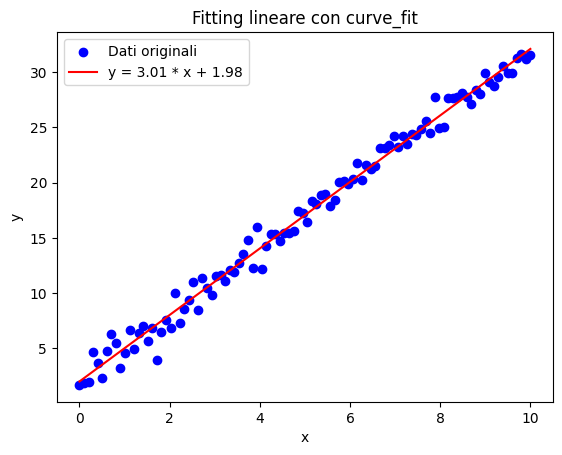

In [105]:
# Plot
y_pred = a * x + b

plt.scatter(x, y, label="Dati originali", color="blue")
plt.plot(x, y_pred, label=esempio, color="red")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Fitting lineare con curve_fit")
plt.legend()
plt.show()